# Exploratory Data Analysis: Two-Column Click Behavior in Qilin

This notebook presents the exploratory data analysis (EDA) for my MSc thesis on click modeling in two-column search and recommendation interfaces.

The goal of this EDA is to understand how click behavior is distributed across position, row, and column in a two-column layout. In particular, I investigate whether user clicks show evidence of examination bias and whether a one-dimensional rank-based view may be insufficient for this interface.

This notebook uses the search split of the Qilin dataset (primary). A corresponding EDA notebook for the recommendation split is also included to assess whether the observed patterns generalize across interaction contexts.

In [54]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [55]:
ds1 = load_dataset("THUIR/Qilin", "search_train")
ds2 = load_dataset("THUIR/Qilin", "search_test")

df1 = ds1["train"].to_pandas()
df2 = ds2["train"].to_pandas()

df = pd.concat([df1, df2], ignore_index=True)

In [57]:
print(df.shape)
print(df.columns)
# df.head()

(50216, 10)
Index(['query', 'query_from_type', 'recent_clicked_note_idxs', 'search_idx',
       'session_idx', 'user_idx', 'dpr_results',
       'search_result_details_with_idx', 'bm25_results', 'search_results'],
      dtype='str')


## Dataset overview

The recommendation data is stored at the request level. Each row corresponds to a recommendation request and contains a list of recommended items together with interaction information.

For click modeling, the request-level format is not yet suitable. Therefore, I transform the nested recommendation results into an item-level table, where each row corresponds to one displayed item.

This makes it possible to analyze click probability at the level of individual displayed positions.

In [58]:
df.loc[0, "search_result_details_with_idx"]

array([{'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 1684016, 'page_time': nan, 'position': 5.0, 'search_timestamp': 1732138228.0, 'share': 0.0},
       {'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 750617, 'page_time': nan, 'position': 6.0, 'search_timestamp': 1732138228.0, 'share': 0.0},
       {'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 1564529, 'page_time': nan, 'position': 7.0, 'search_timestamp': 1732138228.0, 'share': 0.0},
       {'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 741794, 'page_time': nan, 'position': 8.0, 'search_timestamp': 1732138228.0, 'share': 0.0},
       {'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 208988, 'page_time': nan, 'position': 9.0, 'search_timestamp': 1732138230.0, 'share': 0.0},
       {'click': 0.0, 'collect': 0.0, 'comment': 0.0, 'like': 0.0, 'note_idx': 1317926, 'page_time': nan, 'position': 10.0, 'search_timestamp':

## Transforming the nested results into item-level observations

The column `search_result_details_with_idx` contains the displayed recommendation results for each request. Each element includes variables such as click and position.

To analyze position effects, I convert this nested structure into a flat table in which each row corresponds to one displayed item. This is the main table used in the remainder of the EDA.

In [59]:
result_df = df[["session_idx", "search_idx", "search_result_details_with_idx"]].explode("search_result_details_with_idx")
result_df = result_df[result_df["search_result_details_with_idx"].notna()].copy()
result_df.head()

,session_idx,search_idx,search_result_details_with_idx
0,18643,38535,"{'click': 0.0, 'collect': 0.0, 'comment': 0.0,..."
0,18643,38535,"{'click': 0.0, 'collect': 0.0, 'comment': 0.0,..."
0,18643,38535,"{'click': 0.0, 'collect': 0.0, 'comment': 0.0,..."
0,18643,38535,"{'click': 0.0, 'collect': 0.0, 'comment': 0.0,..."
0,18643,38535,"{'click': 0.0, 'collect': 0.0, 'comment': 0.0,..."


In [60]:
result_df = result_df.reset_index(drop=True)

details_df = pd.json_normalize(result_df["search_result_details_with_idx"])

result_df = pd.concat(
    [result_df[["session_idx", "search_idx"]], details_df],
    axis=1
)

result_df.head()

,session_idx,search_idx,click,collect,comment,like,note_idx,page_time,position,search_timestamp,share
0,18643,38535,0.0,0.0,0.0,0.0,1684016,NaN,5.0,1.732138e+09,0.0
1,18643,38535,0.0,0.0,0.0,0.0,750617,NaN,6.0,1.732138e+09,0.0
2,18643,38535,0.0,0.0,0.0,0.0,1564529,NaN,7.0,1.732138e+09,0.0
3,18643,38535,0.0,0.0,0.0,0.0,741794,NaN,8.0,1.732138e+09,0.0
4,18643,38535,0.0,0.0,0.0,0.0,208988,NaN,9.0,1.732138e+09,0.0


In [61]:
print(result_df.columns)
result_df.head()

Index(['session_idx', 'search_idx', 'click', 'collect', 'comment', 'like',
       'note_idx', 'page_time', 'position', 'search_timestamp', 'share'],
      dtype='str')


,session_idx,search_idx,click,collect,comment,like,note_idx,page_time,position,search_timestamp,share
0,18643,38535,0.0,0.0,0.0,0.0,1684016,NaN,5.0,1.732138e+09,0.0
1,18643,38535,0.0,0.0,0.0,0.0,750617,NaN,6.0,1.732138e+09,0.0
2,18643,38535,0.0,0.0,0.0,0.0,1564529,NaN,7.0,1.732138e+09,0.0
3,18643,38535,0.0,0.0,0.0,0.0,741794,NaN,8.0,1.732138e+09,0.0
4,18643,38535,0.0,0.0,0.0,0.0,208988,NaN,9.0,1.732138e+09,0.0


## Selecting variables for the EDA

For this exploratory analysis, I focus on variables that are directly relevant to click behavior and examination bias:

- `session_idx`: identifies the session
- `search_idx`: identifies the search request
- `note_idx`: identifies the item
- `position`: the shown rank/index
- `click`: whether the item was clicked

The analysis later derives `row` and `column` from `position` to represent the two-column layout explicitly.

In [62]:
result_df = result_df[["session_idx", "search_idx", "note_idx", "position", "click"]].copy()
result_df.head()

,session_idx,search_idx,note_idx,position,click
0,18643,38535,1684016,5.0,0.0
1,18643,38535,750617,6.0,0.0
2,18643,38535,1564529,7.0,0.0
3,18643,38535,741794,8.0,0.0
4,18643,38535,208988,9.0,0.0


In [63]:
print("Minimum position:", result_df["position"].min())
print("Maximum position:", result_df["position"].max())
result_df["position"].value_counts().sort_index().head(10)

Minimum position: 0.0
Maximum position: 1005.0


position
0.0      262
1.0    49879
2.0    49773
3.0    49360
4.0    49043
5.0    36147
6.0    33184
7.0    30629
8.0    29136
9.0    27172
Name: count, dtype: int64

## Constructing row and column from position

The interface is treated as a two-column layout. Therefore, the one-dimensional `position` variable is mapped to:

- `row`: vertical placement
- `column`: horizontal placement

Because the minimum observed position is checked directly in the data, row and column are derived from the observed indexing scheme rather than assumed in advance.

In [64]:
result_df["row"] = (result_df["position"] - 1) // 2
result_df["column"] = (result_df["position"] - 1) % 2

In [65]:
result_df[["position", "row", "column", "click"]].head(20)

,position,row,column,click
0,5.0,2.0,0.0,0.0
1,6.0,2.0,1.0,0.0
2,7.0,3.0,0.0,0.0
3,8.0,3.0,1.0,0.0
4,9.0,4.0,0.0,0.0
5,10.0,4.0,1.0,0.0
6,11.0,5.0,0.0,1.0
7,1.0,0.0,0.0,0.0
8,2.0,0.0,1.0,1.0
9,3.0,1.0,0.0,0.0


The constructed variables represent the interface layout more directly than a single rank variable.

- `row = 0` contains the first visible row
- `column = 0` and `column = 1` represent the left and right positions within each row

This transformation allows the analysis to test whether click behavior depends not only on vertical rank, but also on horizontal placement.

In [66]:
result_df.isna().sum()

session_idx    0
search_idx     0
note_idx       0
position       0
click          0
row            0
column         0
dtype: int64

In [67]:
clean_df = result_df.dropna(subset=["position", "click", "row", "column"]).copy()

clean_df["position"] = clean_df["position"].astype(int)
clean_df["click"]    = clean_df["click"].astype(int)
clean_df["row"]      = clean_df["row"].astype(int)
clean_df["column"]   = clean_df["column"].astype(int)

# Filter positions with fewer than 500 impressions — consistent with model notebook
position_counts  = clean_df["position"].value_counts()
valid_positions  = position_counts[position_counts >= 500].index
clean_df         = clean_df[clean_df["position"].isin(valid_positions)].copy()

print("Valid positions kept:", len(valid_positions))
print("Max position:", clean_df["position"].max())
print("Shape after filtering:", clean_df.shape)

clean_df.head()

Valid positions kept: 121
Max position: 123
Shape after filtering: (933473, 7)


,session_idx,search_idx,note_idx,position,click,row,column
0,18643,38535,1684016,5,0,2,0
1,18643,38535,750617,6,0,2,1
2,18643,38535,1564529,7,0,3,0
3,18643,38535,741794,8,0,3,1
4,18643,38535,208988,9,0,4,0


## Basic sanity checks

Before interpreting click-through rates, I first inspect the size and balance of the cleaned impression-level dataset. This is important because CTR estimates can become unstable when some positions have very few observations.

In [68]:
print("Total rows:", len(clean_df))
print("Unique sessions:", clean_df["session_idx"].nunique())
print("Unique requests:", clean_df["search_idx"].nunique())

clean_df["click"].value_counts(normalize=True)

Total rows: 933473
Unique sessions: 29868
Unique requests: 50214


click
0    0.788271
1    0.211729
Name: proportion, dtype: float64

In [69]:
clean_df.describe()

,session_idx,search_idx,note_idx,position,click,row,column
count,933473.000000,933473.000000,9.334730e+05,933473.000000,933473.000000,933473.000000,933473.000000
mean,17735.799547,32274.864746,9.948211e+05,21.329596,0.211729,9.918862,0.491872
std,8614.086728,14626.725089,5.586698e+05,21.858565,0.408534,10.927086,0.499934
min,106.000000,538.000000,6.530000e+02,1.000000,0.000000,0.000000,0.000000
25%,10275.000000,19578.000000,5.081990e+05,5.000000,0.000000,2.000000,0.000000
50%,17658.000000,32373.000000,9.828970e+05,14.000000,0.000000,6.000000,0.000000
75%,25180.000000,45073.000000,1.481316e+06,30.000000,0.000000,14.000000,1.000000
max,32769.000000,57178.000000,1.983935e+06,123.000000,1.000000,61.000000,1.000000


## CTR by position

As a baseline view, I compute CTR by linear position. This checks whether standard position bias is present: items shown earlier should receive more clicks.

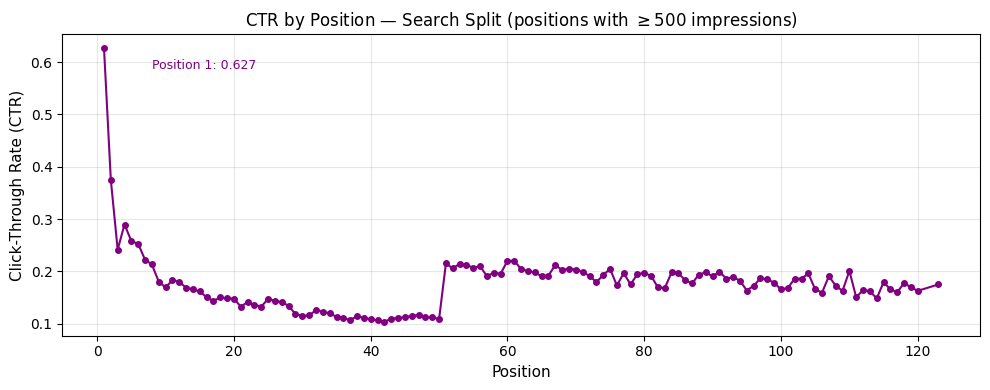

Position 1 CTR: 0.6271
Max position: 123
Total impressions: 933473


In [86]:
ctr_position      = clean_df.groupby("position")["click"].mean()
exposure_position = clean_df.groupby("position").size()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(ctr_position.index, ctr_position.values, 
        marker="o", markersize=4, color="purple", linewidth=1.5)

# Annotate first position
ax.annotate(f"Position 1: {ctr_position[1]:.3f}",
            xy=(1, ctr_position[1]),
            xytext=(8, ctr_position[1] - 0.04),
            fontsize=9, color="purple")

ax.set_xlabel("Position", fontsize=11)
ax.set_ylabel("Click-Through Rate (CTR)", fontsize=11)
ax.set_title("CTR by Position — Search Split (positions with $\\geq$500 impressions)", fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ctr_by_position_search.png", dpi=150)
plt.show()

print(f"Position 1 CTR: {ctr_position[1]:.4f}")
print(f"Max position: {clean_df['position'].max()}")
print(f"Total impressions: {len(clean_df)}")

## CTR by row

This plot aggregates click behavior at the row level. If CTR decreases with row, this suggests vertical position bias: users are more likely to examine items near the top of the interface.

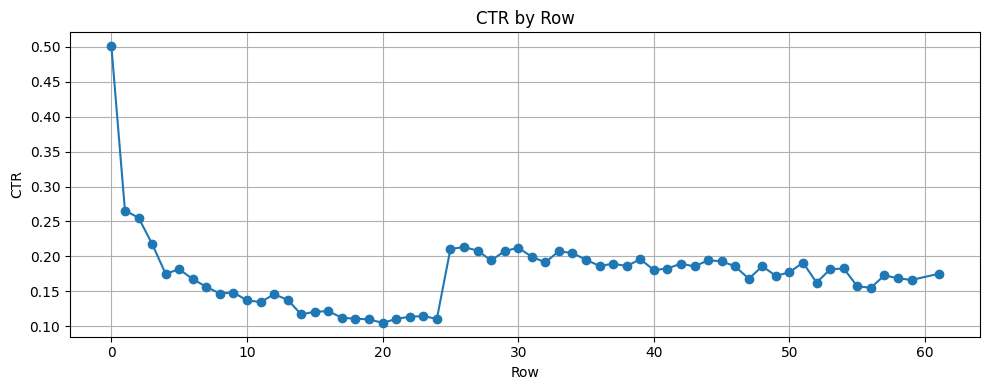

CTR by row:
row
0     0.5011
1     0.2656
2     0.2554
3     0.2179
4     0.1750
5     0.1816
6     0.1673
7     0.1563
8     0.1467
9     0.1481
10    0.1370
11    0.1345
12    0.1456
13    0.1377
14    0.1167
15    0.1207
16    0.1214
17    0.1120
18    0.1106
19    0.1097
20    0.1047
21    0.1103
22    0.1135
23    0.1144
24    0.1105
25    0.2105
26    0.2133
27    0.2082
28    0.1941
29    0.2074
30    0.2125
31    0.1993
32    0.1913
33    0.2075
34    0.2045
35    0.1952
36    0.1861
37    0.1895
38    0.1861
39    0.1959
40    0.1804
41    0.1825
42    0.1895
43    0.1855
44    0.1944
45    0.1929
46    0.1856
47    0.1678
48    0.1858
49    0.1719
50    0.1773
51    0.1909
52    0.1624
53    0.1814
54    0.1826
55    0.1571
56    0.1549
57    0.1727
58    0.1686
59    0.1662
61    0.1750


In [87]:
ctr_row = clean_df.groupby("row")["click"].mean()

plt.figure(figsize=(10, 4))
plt.plot(ctr_row.index, ctr_row.values, marker="o")
plt.xlabel("Row")
plt.ylabel("CTR")
plt.title("CTR by Row")
plt.grid(True)
plt.tight_layout()
plt.savefig("ctr_by_row.png", dpi=150)
plt.show()

print("CTR by row:")
print(ctr_row.round(4).to_string())

## CTR by column

This analysis tests whether horizontal placement matters. If the two columns have different CTR, then a purely one-dimensional ranked-list view may miss part of the examination process.

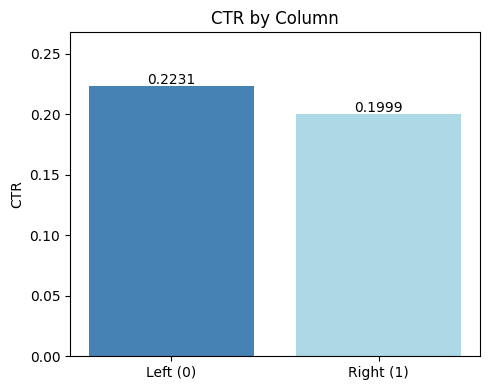

=== Chi-square test: Left vs Right column CTR ===
Left CTR:  0.2231
Right CTR: 0.1999
Chi2: 753.18  df: 1  p-value: 0.000000
Conclusion: Statistically significant difference


In [88]:
ctr_column = clean_df.groupby("column")["click"].mean()

plt.figure(figsize=(5, 4))
plt.bar(["Left (0)", "Right (1)"], ctr_column.values, color=["steelblue", "lightblue"])
plt.ylabel("CTR")
plt.title("CTR by Column")
plt.ylim(0, ctr_column.max() * 1.2)
for i, v in enumerate(ctr_column.values):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.savefig("ctr_by_column.png", dpi=150)
plt.show()

# Chi-square test for column CTR difference
contingency = pd.crosstab(clean_df["column"], clean_df["click"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("=== Chi-square test: Left vs Right column CTR ===")
print(f"Left CTR:  {ctr_column[0]:.4f}")
print(f"Right CTR: {ctr_column[1]:.4f}")
print(f"Chi2: {chi2:.2f}  df: {dof}  p-value: {p:.6f}")
print(f"Conclusion: {'Statistically significant difference' if p < 0.05 else 'No significant difference'}")

## Column CTR by Row — Anomaly Check

This table shows CTR for left and right columns separately for each row.

- If left CTR consistently exceeds right CTR, that confirms a left-column advantage.
- Rows where right CTR exceeds left CTR are anomalies worth investigating.
- A consistent anomaly at a specific row suggests a scanning pattern deviation rather than noise.

In [89]:
print("=== Column CTR by Row (all rows) ===")
print(f"{'Row':<6} {'Left CTR':>10} {'Right CTR':>11} {'Left > Right':>14}")
print("-" * 45)

for row in sorted(clean_df["row"].unique()):
    subset     = clean_df[clean_df["row"] == row]
    left_ctr   = subset[subset["column"] == 0]["click"].mean()
    right_ctr  = subset[subset["column"] == 1]["click"].mean()
    flag       = "YES" if left_ctr > right_ctr else "NO ← anomaly"
    print(f"{row:<6} {left_ctr:>10.4f} {right_ctr:>11.4f} {flag:>14}")


=== Column CTR by Row (all rows) ===
Row      Left CTR   Right CTR   Left > Right
---------------------------------------------
0          0.6271      0.3748            YES
1          0.2416      0.2896   NO ← anomaly
2          0.2580      0.2526            YES
3          0.2224      0.2132            YES
4          0.1806      0.1693            YES
5          0.1830      0.1801            YES
6          0.1689      0.1657            YES
7          0.1617      0.1505            YES
8          0.1436      0.1502   NO ← anomaly
9          0.1481      0.1481            YES
10         0.1324      0.1415   NO ← anomaly
11         0.1362      0.1327            YES
12         0.1475      0.1436            YES
13         0.1412      0.1340            YES
14         0.1183      0.1152            YES
15         0.1156      0.1260   NO ← anomaly
16         0.1230      0.1196            YES
17         0.1133      0.1107            YES
18         0.1070      0.1143   NO ← anomaly
19         0.1110

In [90]:
ctr_2d = clean_df.pivot_table(
    values="click",
    index="row",
    columns="column",
    aggfunc="mean"
)

ctr_2d

column,0,1
row,,
0,0.627078,0.374842
1,0.241633,0.289623
2,0.258030,0.252561
3,0.222404,0.213241
4,0.180590,0.169265
...,...,...
56,0.162063,0.148276
57,0.179348,0.165714
58,0.160291,0.177645


## CTR heatmap by (row, column)

This heatmap shows CTR for each two-dimensional position in the layout. Under a purely one-dimensional model, both cells within a row would be expected to behave similarly. Visible within-row differences motivate the two-dimensional extension. The exposure count heatmap is shown alongside to confirm that observed patterns are not driven by data sparsity.

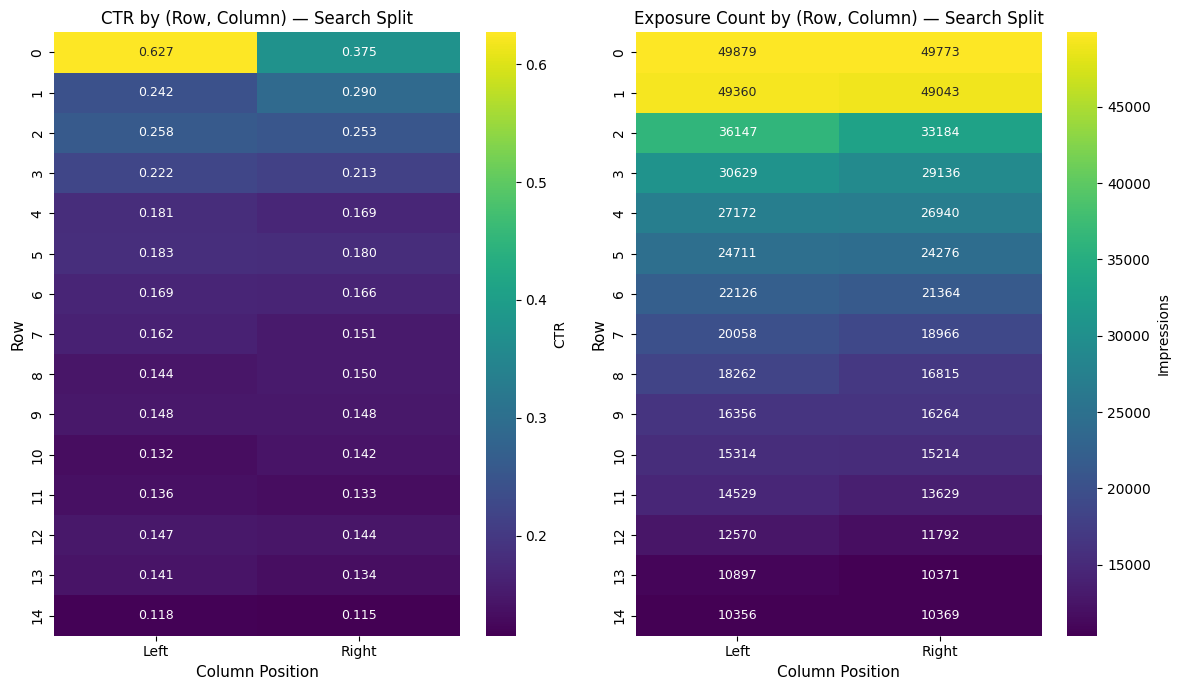

In [91]:
exposure_2d = clean_df.pivot_table(
    values="click",
    index="row",
    columns="column",
    aggfunc="count"
)

# Rename columns for clarity
ctr_2d_plot = ctr_2d.copy()
ctr_2d_plot.columns = ["Left", "Right"]
exposure_2d_plot = exposure_2d.copy()
exposure_2d_plot.columns = ["Left", "Right"]

# Limit to first 15 rows for readability
ctr_2d_plot     = ctr_2d_plot.iloc[:15]
exposure_2d_plot = exposure_2d_plot.iloc[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

sns.heatmap(ctr_2d_plot, annot=True, fmt=".3f", cmap="viridis",
            ax=axes[0], cbar_kws={"label": "CTR"},
            annot_kws={"size": 9})
axes[0].set_title("CTR by (Row, Column) — Search Split", fontsize=12)
axes[0].set_xlabel("Column Position", fontsize=11)
axes[0].set_ylabel("Row", fontsize=11)

sns.heatmap(exposure_2d_plot, annot=True, fmt=".0f", cmap="viridis",
            ax=axes[1], cbar_kws={"label": "Impressions"},
            annot_kws={"size": 9})
axes[1].set_title("Exposure Count by (Row, Column) — Search Split", fontsize=12)
axes[1].set_xlabel("Column Position", fontsize=11)
axes[1].set_ylabel("Row", fontsize=11)


plt.tight_layout()
plt.savefig("ctr_and_exposure_heatmap_search.png", dpi=150)
plt.show()

In [ ]:
# Sort by position (top first)
clean_df_sorted = clean_df.sort_values(by=["session_idx", "position"])

# Get first click per session
first_clicks = clean_df_sorted[clean_df_sorted["click"] == 1] \
    .groupby("session_idx") \
    .first()

first_clicks[["row", "column"]].head(20)

,row,column
session_idx,,
106,0,0
426,4,1
830,1,1
1732,0,0
1989,0,0
2042,0,0
2906,0,1
2907,2,1
2908,0,1


: 

## Exposure by row

To determine which rows are reliable enough to interpret, I inspect the number of impressions per row. Deep rows may contain too little data for stable CTR estimates.

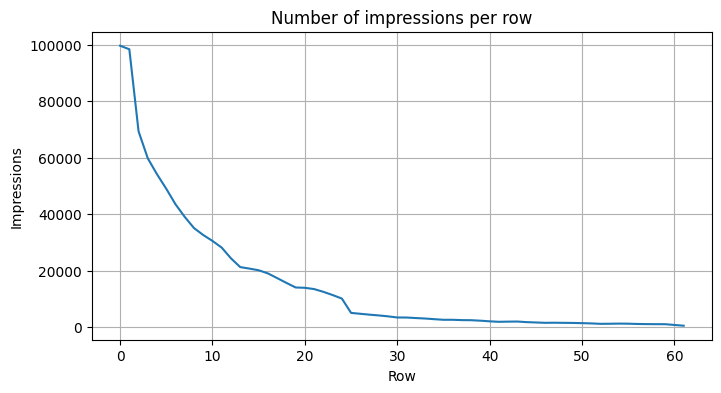

(row
 0     99652
 1     98403
 2     69331
 3     59765
 4     54112
 5     48987
 6     43490
 7     39024
 8     35077
 9     32620
 10    30528
 11    28158
 12    24362
 13    21268
 14    20725
 15    20142
 16    19027
 17    17360
 18    15672
 19    14045
 dtype: int64,
 row
 41    1890
 42    1952
 43    1984
 44    1775
 45    1654
 46    1530
 47    1561
 48    1523
 49    1489
 50    1416
 51    1320
 52    1170
 53    1202
 54    1254
 55    1222
 56    1123
 57    1077
 58    1050
 59    1041
 61     503
 dtype: int64)

In [92]:
counts_row = clean_df.groupby("row").size()

plt.figure(figsize=(8,4))
counts_row.plot()
plt.xlabel("Row")
plt.ylabel("Impressions")
plt.title("Number of impressions per row")
plt.grid(True)
plt.show()

counts_row.head(20), counts_row.tail(20)

## First-click analysis

As an exploratory proxy for examination order, I inspect the position of the first click within each request. If first clicks are concentrated in the top-left area, this is consistent with a top-down, left-to-right scanning pattern.

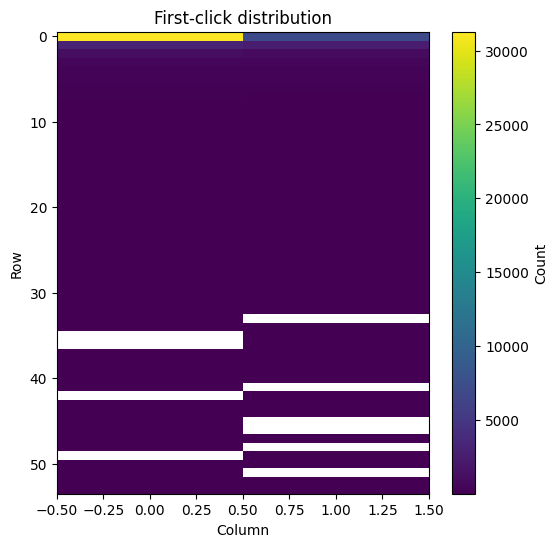

In [93]:
first_clicks = (
    clean_df[clean_df["click"] == 1]
    .sort_values(["session_idx", "search_idx", "position"])
    .groupby(["session_idx", "search_idx"])
    .first()
    .reset_index()
)

first_click_dist = first_clicks.pivot_table(
    index="row",
    columns="column",
    values="click",
    aggfunc="count"
)

plt.figure(figsize=(6,6))
plt.imshow(first_click_dist, aspect="auto")
plt.colorbar(label="Count")
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("First-click distribution")
plt.show()

In [94]:
print(len(clean_df))
print(clean_df["session_idx"].nunique())
print(clean_df["search_idx"].nunique())
print(clean_df["click"].mean())

933473
29868
50214
0.21172867345922164


In [95]:
total_first_clicks = len(first_clicks)

summary = (
    first_clicks
    .groupby(["row", "column"])
    .size()
    .reset_index(name="count")
)
summary["share"] = summary["count"] / total_first_clicks

print("=== First-click distribution by (row, column) — top 10 rows ===")
print(summary[summary["row"] <= 9].to_string(index=False))

print(f"\nTotal first clicks:                    {total_first_clicks}")
print(f"Share in row 0:                        {summary[summary['row']==0]['share'].sum():.3f}")
print(f"Share in left column (col 0):          {summary[summary['column']==0]['share'].sum():.3f}")
print(f"Share in right column (col 1):         {summary[summary['column']==1]['share'].sum():.3f}")

top_left  = summary[(summary['row']==0) & (summary['column']==0)]
top_right = summary[(summary['row']==0) & (summary['column']==1)]

if len(top_left) > 0:
    print(f"Share in top-left cell (row 0, col 0): {top_left['share'].values[0]:.3f}")
if len(top_right) > 0:
    print(f"Share in top-right cell (row 0, col 1):{top_right['share'].values[0]:.3f}")

=== First-click distribution by (row, column) — top 10 rows ===
 row  column  count    share
   0       0  31274 0.623224
   0       1   7054 0.140571
   1       0   3019 0.060162
   1       1   2539 0.050597
   2       0   1106 0.022040
   2       1    862 0.017178
   3       0    596 0.011877
   3       1    492 0.009805
   4       0    312 0.006217
   4       1    301 0.005998
   5       0    297 0.005919
   5       1    254 0.005062
   6       0    192 0.003826
   6       1    160 0.003188
   7       0    153 0.003049
   7       1    105 0.002092
   8       0    120 0.002391
   8       1     98 0.001953
   9       0     97 0.001933
   9       1     81 0.001614

Total first clicks:                    50181
Share in row 0:                        0.764
Share in left column (col 0):          0.751
Share in right column (col 1):         0.249
Share in top-left cell (row 0, col 0): 0.623
Share in top-right cell (row 0, col 1):0.141


In [97]:
print("=== SEARCH SPLIT ===")
print(f"Left CTR: {clean_df[clean_df['column']==0]['click'].mean():.4f}")
print(f"Right CTR: {clean_df[clean_df['column']==1]['click'].mean():.4f}")
contingency = pd.crosstab(clean_df["column"], clean_df["click"])
chi2, p, dof, _ = chi2_contingency(contingency)
print(f"Chi2: {chi2:.2f}  p: {p:.6f}")

first_clicks_total = len(first_clicks)
top_left = first_clicks[(first_clicks['row']==0) & (first_clicks['column']==0)]
top_right = first_clicks[(first_clicks['row']==0) & (first_clicks['column']==1)]
print(f"Top-left share: {len(top_left)/first_clicks_total:.3f}")
print(f"Top-right share: {len(top_right)/first_clicks_total:.3f}")

=== SEARCH SPLIT ===
Left CTR: 0.2231
Right CTR: 0.1999
Chi2: 753.18  p: 0.000000
Top-left share: 0.623
Top-right share: 0.141
